# RAG project on the Archelec corpus

This notebook builds a Retrieval-Augmented Generation (RAG) pipeline on French legislative manifestos from 1988.

It includes a **data analysis section** before the modeling steps, in order to justify the preprocessing and retrieval choices:
- corpus size and document length statistics,
- distribution of document lengths,
- most frequent words after cleaning,
- lexical diversity,
- thematic proximity between documents with TF-IDF cosine similarity.

The goal is to show that the modeling choices are grounded in the structure of the corpus, and not only in technical convenience.


In [1]:
# Install required packages
!pip install -q python-dotenv faiss-cpu langchain-huggingface sentence-transformers langchain_community langchain-text-splitters IPython pandas matplotlib scikit-learn


In [2]:
# Imports
import os
import re
from dotenv import load_dotenv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import display, Markdown


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

## 1. Load the corpus


In [4]:
# Load text files
base_path = Path("text_files")

documents = []
file_names = []

for path in sorted(base_path.rglob("*.txt")):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
        if text:
            documents.append(text)
            file_names.append(path.name)

print(f"Number of loaded text files: {len(documents)}")
print("First file:", file_names[0] if file_names else "No file found")


Number of loaded text files: 3628
First file: EL174_L_1988_06_001_01_1_PF_01.txt


In [5]:
# Build a dataframe for corpus analysis
corpus_df = pd.DataFrame({
    "file_name": file_names,
    "text": documents
})

corpus_df["n_characters"] = corpus_df["text"].str.len()
corpus_df["n_words"] = corpus_df["text"].str.split().str.len()
corpus_df["n_lines"] = corpus_df["text"].str.count(r"\n") + 1

corpus_df.head()


,file_name,text,n_characters,n_words,n_lines
0,EL174_L_1988_06_001_01_1_PF_01.txt,Élections Législatives du 5 Juin 1988 - Départ...,3090,508,29
1,EL174_L_1988_06_001_01_1_PF_02.txt,RÉPUBLIQUE FRANÇAISE - Liberté - Égalité - Fra...,3602,591,38
2,EL174_L_1988_06_001_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...,5007,812,30
3,EL174_L_1988_06_001_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,1664,257,23
4,EL174_L_1988_06_001_01_1_PF_05.txt,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,4225,675,37


## 2. Data analysis

This section documents the main textual properties of the corpus before chunking and embedding.


In [6]:
# Basic corpus statistics
n_documents = len(corpus_df)
total_words = int(corpus_df["n_words"].sum())
avg_words = corpus_df["n_words"].mean()
median_words = corpus_df["n_words"].median()
min_words = int(corpus_df["n_words"].min())
max_words = int(corpus_df["n_words"].max())

summary_stats = pd.DataFrame({
    "Metric": [
        "Number of documents",
        "Total number of words",
        "Average number of words per document",
        "Median number of words per document",
        "Minimum number of words",
        "Maximum number of words"
    ],
    "Value": [
        n_documents,
        total_words,
        round(avg_words, 2),
        round(median_words, 2),
        min_words,
        max_words
    ]
})

summary_stats


,Metric,Value
0,Number of documents,3628.00
1,Total number of words,2002003.00
2,Average number of words per document,551.82
3,Median number of words per document,495.00
4,Minimum number of words,9.00
5,Maximum number of words,2552.00


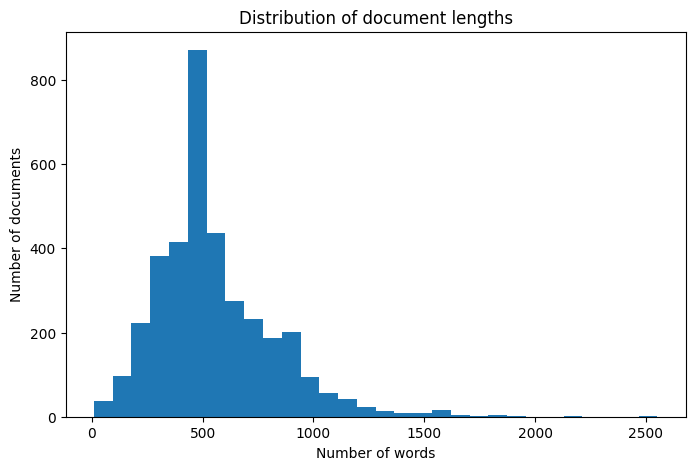

In [7]:
# Distribution of document lengths
plt.figure(figsize=(8, 5))
plt.hist(corpus_df["n_words"], bins=30)
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.title("Distribution of document lengths")
plt.show()


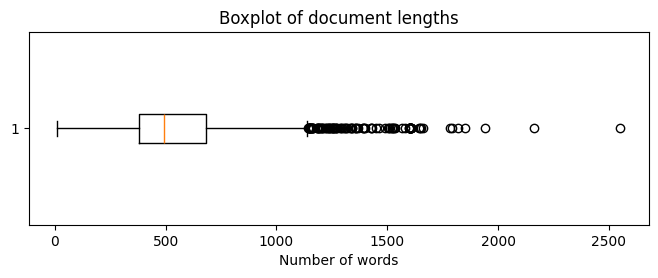

In [8]:
# Boxplot of document lengths
plt.figure(figsize=(8, 2.5))
plt.boxplot(corpus_df["n_words"], vert=False)
plt.xlabel("Number of words")
plt.title("Boxplot of document lengths")
plt.show()

### Text cleaning for exploratory analysis

The following preprocessing is only used for descriptive analysis:
- lowercasing,
- removal of punctuation and digits,
- stopword filtering.


In [9]:
# Minimal French stopword list for corpus exploration
french_stopwords = {
    "alors", "au", "aucuns", "aussi", "autre", "avant", "avec", "avoir", "bon", "car",
    "ce", "cela", "ces", "ceux", "chaque", "ci", "comme", "comment", "dans", "des",
    "du", "dedans", "dehors", "depuis", "devrait", "doit", "donc", "dos", "début",
    "elle", "elles", "en", "encore", "essai", "est", "et", "eu", "fait", "faites",
    "fois", "font", "hors", "ici", "il", "ils", "je", "juste", "la", "le", "les",
    "leur", "là", "ma", "maintenant", "mais", "mes", "mine", "moins", "mon", "mot",
    "même", "ni", "nommés", "notre", "nous", "nouveaux", "ou", "où", "par", "parce",
    "parole", "pas", "personnes", "peut", "peu", "pièce", "plupart", "pour", "pourquoi",
    "quand", "que", "quel", "quelle", "quelles", "quels", "qui", "sa", "sans", "ses",
    "seulement", "si", "sien", "son", "sont", "sous", "soyez", "sujet", "sur", "ta",
    "tandis", "tellement", "tels", "tes", "ton", "tous", "tout", "trop", "très", "tu",
    "voient", "vont", "votre", "vous", "vu", "ça", "étaient", "état", "étions", "été",
    "être", "cette", "cet", "d", "l", "c", "j", "n", "s", "y", "a", "à", "un", "une"
}

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s-]", " ", text)
    text = text.replace("-", " ")
    tokens = text.split()
    tokens = [tok for tok in tokens if tok not in french_stopwords and len(tok) > 2]
    return tokens

corpus_df["tokens"] = corpus_df["text"].apply(clean_and_tokenize)
corpus_df["n_clean_tokens"] = corpus_df["tokens"].apply(len)

corpus_df[["file_name", "n_words", "n_clean_tokens"]].head()


,file_name,n_words,n_clean_tokens
0,EL174_L_1988_06_001_01_1_PF_01.txt,508,266
1,EL174_L_1988_06_001_01_1_PF_02.txt,591,321
2,EL174_L_1988_06_001_01_1_PF_03.txt,812,403
3,EL174_L_1988_06_001_01_1_PF_04.txt,257,146
4,EL174_L_1988_06_001_01_1_PF_05.txt,675,354


In [10]:
# Most frequent words in the corpus
all_tokens = [token for tokens in corpus_df["tokens"] for token in tokens]
token_counts = Counter(all_tokens)

top_words_df = pd.DataFrame(token_counts.most_common(20), columns=["word", "frequency"])
top_words_df


,word,frequency
0,france,8310
1,fonds,7731
2,juin,7608
3,aux,6611
4,cevipof,6467
5,plus,6367
6,ont,6140
7,sciences,5979
8,circonscription,5852
9,politique,5341


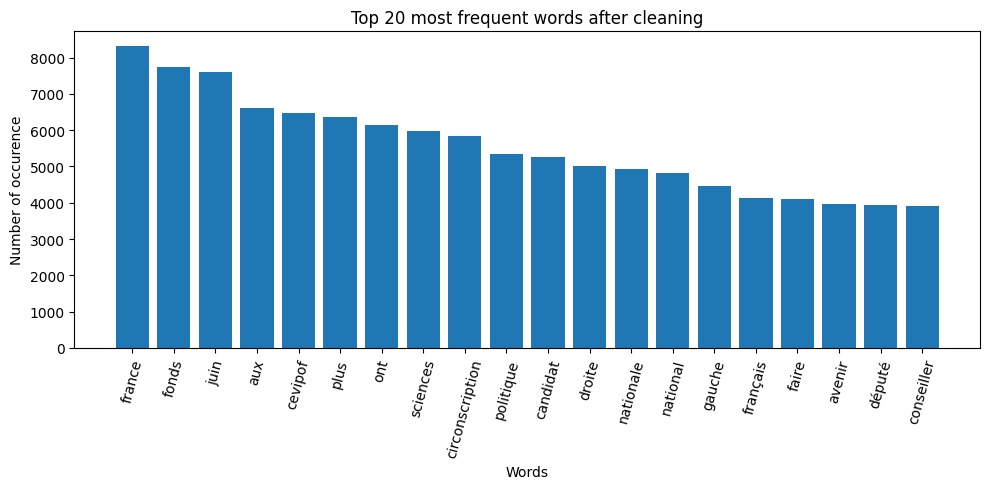

In [11]:
# Bar plot of the most frequent words
plt.figure(figsize=(10, 5))
plt.bar(top_words_df["word"], top_words_df["frequency"])
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Number of occurence")
plt.title("Top 20 most frequent words after cleaning")
plt.tight_layout()
plt.show()

In [12]:
# Lexical diversity
unique_words = len(set(all_tokens))
total_clean_tokens = len(all_tokens)
lexical_diversity = unique_words / total_clean_tokens if total_clean_tokens > 0 else 0

lexical_diversity_df = pd.DataFrame({
    "Metric": ["Unique cleaned words", "Total cleaned tokens", "Lexical diversity"],
    "Value": [unique_words, total_clean_tokens, round(lexical_diversity, 4)]
})

lexical_diversity_df


,Metric,Value
0,Unique cleaned words,4.496300e+04
1,Total cleaned tokens,1.075337e+06
2,Lexical diversity,4.180000e-02


In [13]:
# Average cosine similarity between documents using TF-IDF
# This gives a simple measure of thematic proximity in the corpus.

vectorizer = TfidfVectorizer(max_features=3000, stop_words=list(french_stopwords))
tfidf_matrix = vectorizer.fit_transform(corpus_df["text"])

similarity_matrix = cosine_similarity(tfidf_matrix)
np.fill_diagonal(similarity_matrix, np.nan)

mean_similarity = np.nanmean(similarity_matrix)
median_similarity = np.nanmedian(similarity_matrix)
max_similarity = np.nanmax(similarity_matrix)

similarity_summary = pd.DataFrame({
    "Metric": [
        "Mean pairwise cosine similarity",
        "Median pairwise cosine similarity",
        "Maximum pairwise cosine similarity"
    ],
    "Value": [
        round(float(mean_similarity), 4),
        round(float(median_similarity), 4),
        round(float(max_similarity), 4)
    ]
})

similarity_summary


,Metric,Value
0,Mean pairwise cosine similarity,0.2606
1,Median pairwise cosine similarity,0.2519
2,Maximum pairwise cosine similarity,1.0000


## 3. Prepare documents for the RAG pipeline

In [14]:
# Wrap each raw text into a LangChain Document
docs = [
    Document(
        page_content=text,
        metadata={"source": file_name}
    )
    for text, file_name in zip(documents, file_names)
]

len(docs)

3628

In [15]:
# Chunk the documents
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(docs)

print(f"Number of chunks: {len(chunks)}")
print()
print("Example of chunk metadata:")
print(chunks[0].metadata if chunks else "No chunk created")


Number of chunks: 16815

Example of chunk metadata:
{'source': 'EL174_L_1988_06_001_01_1_PF_01.txt'}


## 4. Build embeddings and the vector database

In [16]:
# Embedding model
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9644.66it/s]


In [17]:
# Create the FAISS vector database
faiss_db = FAISS.from_documents(chunks, embedding_model)

## 5. Build the retrieval system

In [18]:
def retrieve_docs(query, k=5):
    retrieved = faiss_db.similarity_search(query, k=k)

    results = []
    for doc in retrieved:
        results.append({
            "chunk": doc.page_content,
            "metadata": doc.metadata
        })

    return results


In [19]:
# Test retrieval
query = "Quel est le parti dominant en France ?"
retrieved_docs = retrieve_docs(query, k=3)
retrieved_docs


[{'chunk': "Ainsi, pour la région comme pour la France, le choix du 5 juin c'est\nYvette ROUDY et\nPhilippe VACHER\nimp. le brun, caen. 31 74 48 52 ☐ ☒",
  'metadata': {'source': 'EL174_L_1988_06_014_03_1_PF_03.txt'}},
 {'chunk': '· Parce que la Majorité Présidentielle pour la France Unie a besoin de lui.\nDès le premier tour, le 5 juin\nVotez pour la France Unie\nVotez Guy VAXELAIRE\nVU LE CANDIDAT\nImp. du Capucin - Charmes ☒ ☒ ☒',
  'metadata': {'source': 'EL177_L_1988_06_088_03_1_PF_05.txt'}},
 {'chunk': "Ainsi, pour la région comme pour la France, le choix du 12 juin c'est\nYvette ROUDY et Philippe VACHER\nimp. le brun. caen, 31.74 48 52 ☐ ☐ ☐ ☐",
  'metadata': {'source': 'EL174_L_1988_06_014_03_2_PF_01.txt'}}]

In [20]:
# Read the Hugging Face token from the environment
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

if hf_token is None:
    print("No Hugging Face token found in the environment.")
    print("Set HUGGINGFACEHUB_API_TOKEN before running the generation cells.")
else:
    print("Hugging Face token detected.")

Hugging Face token detected.


In [21]:
# Load the LLM
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token=hf_token
)

chat_model = ChatHuggingFace(llm=llm)


## 7. Build the RAG system

In [22]:
def ask_llm_with_context(query, context):
    messages = [
        SystemMessage(
            content=(
                "Tu es un journaliste politique spécialisé dans les élections législatives françaises de 1988. "
                "Tu dois répondre de manière factuelle et rigoureuse uniquement à partir du contexte fourni, "
                "qui est constitué de manifestes électoraux de cette période. "
                "Tu n'inventes jamais d'information. "
                "Si la réponse ne se trouve pas dans le contexte, tu dois dire clairement que tu ne sais pas."
            )
        ),
        HumanMessage(
            content=f"""
Question: {query}

Contexte:
{context}

Rédige une réponse courte, factuelle et strictement fondée sur ce contexte.
"""
        )
    ]

    response = chat_model.invoke(messages)
    return response.content


In [23]:
def ask_rag(query, k=5, display_answer=True):
    retrieved = retrieve_docs(query, k=k)

    context = "\n\n".join(
        [f"Source: {item['metadata'].get('source', 'unknown')}\n{item['chunk']}" for item in retrieved]
    )

    answer = ask_llm_with_context(query, context)

    if display_answer:
        display(Markdown(answer))

    return {
        "query": query,
        "retrieved_documents": retrieved,
        "context": context,
        "answer": answer
    }


In [24]:
# Test the full RAG system
query = "Que disent les manifestes sur l'Europe ?"
result = ask_rag(query, k=5)

D'après les manifestes électoraux de 1988, les partis suivants ont exprimé leurs positions sur l'Europe :

* Le candidat Hults (RÉUSSIR LA FRANCE UNIE) n'a pas exprimé clairement sa position sur l'Europe.
* Le candidat Pierre MONTASTRUC (DUSTRATION Lieve Montity) a exprimé son soutien à l'ouverture du Sud du Département à l'Europe, en particulier pour améliorer le passage du Val d'Aran et en faire un véritable lien européen avec l'Espagne.
* Le candidat Philippe MERCANTE (Votez Philippe MERCANTE) a exprimé une opposition à la politique dite de "l'Europe de 92", qui selon lui signifie la régression sociale et démocratique, la foire aux capitaux, le surarmement accéléré et le déclin national.
* Le candidat sans nom (EL177_L_1988_06_089_03_1_PF_04.txt) a également exprimé une opposition à la politique de l'Europe de 92, mais sans fournir de détails supplémentaires.

Il est important de noter que les positions exprimées sur l'Europe dans ces manifestes peuvent varier en intensité et en précision.

In [25]:
# Example of a question outside the corpus scope
query = "Qui est Emmanuel Macron ?"
result_out_of_scope = ask_rag(query, k=5)

Désolé, mais je ne peux pas trouver d'information sur Emmanuel Macron dans le contexte fourni. Il n'est pas mentionné dans aucun des manifestes électoraux que j'ai pu analyser. Je ne peux donc pas fournir de réponse précise à votre question.

In [26]:
# Mini-évaluation RAG vs LLM seul

questions = [
    "Que disent les programmes électoraux de 1988 au sujet du chômage en France selon les documents sur les manifestes politiques français de 1988?",
    "Comment aborde-t-on la question de l'éducation en 1988 en France selon les documents sur les manifestes politiques français de 1988?",
    "Que dit-on de la France en 1988 selon les documents sur les manifestes politiques français de 1988?",
    "Qu'en est-il de la politique économique de la France en 1988 selon les documents sur les manifestes politiques français de 1988?",
    "Comment aborde-t-on la question de l'immigration en France en 1988 selon les documents sur les manifestes politiques français de 1988 ?"
]

rag_answers = []
llm_answers = []
contexts = []

for q in questions:
    # Réponse avec RAG
    rag_result = ask_rag(q, k=5, display_answer=False)
    rag_answers.append(rag_result["answer"])
    contexts.append(rag_result["context"])

    # Réponse sans RAG
    messages = [
        SystemMessage(
            content="Tu es un assistant spécialisé dans l'analyse de textes politiques français."
        ),
        HumanMessage(
            content=f"Réponds à la question suivante : {q}"
        )
    ]

    llm_response = chat_model.invoke(messages)
    llm_answers.append(llm_response.content)


df_eval = pd.DataFrame({
    "question": questions,
    "rag_answer": rag_answers,
    "llm_answer": llm_answers,
    "context": contexts
})


# Métrique simple : part des mots de la réponse présents dans le contexte récupéré

rag_scores = []
llm_scores = []

for i in range(len(df_eval)):
    context_words = set(clean_and_tokenize(df_eval.loc[i, "context"]))

    rag_words = set(clean_and_tokenize(df_eval.loc[i, "rag_answer"]))
    llm_words = set(clean_and_tokenize(df_eval.loc[i, "llm_answer"]))

    rag_score = len(rag_words.intersection(context_words)) / len(rag_words) if len(rag_words) > 0 else 0
    llm_score = len(llm_words.intersection(context_words)) / len(llm_words) if len(llm_words) > 0 else 0

    rag_scores.append(rag_score)
    llm_scores.append(llm_score)

df_eval["rag_grounded_score"] = rag_scores
df_eval["llm_grounded_score"] = llm_scores

print("Score moyen RAG :", df_eval["rag_grounded_score"].mean())
print("Score moyen LLM seul :", df_eval["llm_grounded_score"].mean())

df_eval[["question", "rag_grounded_score", "llm_grounded_score"]]

Score moyen RAG : 0.5853866453181521
Score moyen LLM seul : 0.14835955353287258


,question,rag_grounded_score,llm_grounded_score
0,Que disent les programmes électoraux de 1988 a...,0.531250,0.172414
1,Comment aborde-t-on la question de l'éducation...,0.520548,0.166667
2,Que dit-on de la France en 1988 selon les docu...,0.593750,0.102804
3,Qu'en est-il de la politique économique de la ...,0.690476,0.153846
4,Comment aborde-t-on la question de l'immigrati...,0.590909,0.146067
